# Multivariate Resemblance Analysis (MRA) Dataset A
In this notebook the multivariate resemblance analysis of Dataset A is performed for all STDG approaches.

In [1]:
#import libraries
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import os
print('Libraries imported!!')

Libraries imported!!


In [2]:
#define directory of functions and actual directory
FUNCTIONS_HOME = '../../../functions/evaluation_functions/'
REAL_DATA_HOME = '../../../data/raw/rembrandt/'
SYN_DATA_HOME  = '../../../data/processed/rembrandt/'
FUNCTIONS_DIR = 'EVALUATION FUNCTIONS/RESEMBLANCE'
ACTUAL_DIR = os.getcwd()

#change directory to functions directory
os.chdir(FUNCTIONS_HOME + FUNCTIONS_DIR)

#import functions for univariate resemblance analisys
from multivariate_resemblance import get_numerical_correlations
from multivariate_resemblance import plot_correlations
from multivariate_resemblance import get_categorical_correlations
from multivariate_resemblance import compute_mra_score

#change directory to actual directory
os.chdir(ACTUAL_DIR)
print('Functions imported!!')

Functions imported!!


## 1. Read real and synthetic datasets
In this part real and synthetic datasets are read.

In [3]:
#Define global variables
DATA_TYPES = ['Real','GM','SDV','CTGAN','WGANGP', 'ECDF']
SYNTHESIZERS = ['GM','SDV','CTGAN','WGANGP', 'ECDF']
FILEPATHS = {'Real' : REAL_DATA_HOME + '0_Depression_Data_Real_Train.csv',
            'GM' : SYN_DATA_HOME + '0_Depression_Data_Synthetic_GM.csv',
            'SDV' : SYN_DATA_HOME + '0_Depression_Data_Synthetic_SDV.csv',
            'CTGAN' : SYN_DATA_HOME + '0_Depression_Data_Synthetic_CTGAN.csv',
            'WGANGP' : SYN_DATA_HOME + '0_Depression_Data_Synthetic_WGANGP.csv',
            'ECDF' : SYN_DATA_HOME + '0_Depression_Data_Synthetic_ECDF.csv'}
categorical_columns = ['group']
data = dict()

In [4]:
#iterate over all datasets filepaths and read each dataset
for name, path in FILEPATHS.items() :
    data[name] = pd.read_csv(path)
    for col in categorical_columns :
        data[name][col] = data[name][col].astype('category')
data

{'Real':        group       ma1     hars1       ma2     hars2       ma3     hars3  \
 0    Control -0.872369 -0.943320 -0.872369 -0.943320 -0.872369 -1.130271   
 1   Remitted  0.628481  0.926183 -0.309550 -0.569420  0.816087 -0.569420   
 2   Remitted -0.121944 -0.195519 -0.872369 -0.756370 -0.497156 -0.008569   
 3   Remitted  0.816087  0.739233 -0.309550 -0.569420 -0.121944  0.739233   
 4   Remitted  1.003693  2.047885  0.253268  2.234835  0.628481  1.487034   
 ..       ...       ...       ...       ...       ...       ...       ...   
 91   Control -0.872369 -0.382469 -0.309550  0.178382 -0.684762 -0.756370   
 92   Control -0.872369 -0.569420 -0.684762 -0.195519 -0.872369 -0.756370   
 93   Control -0.684762 -0.943320 -0.684762 -0.756370 -0.497156 -0.943320   
 94   Control -0.684762 -0.756370 -0.872369 -0.756370 -0.872369 -0.943320   
 95  Remitted -0.684762 -0.569420 -0.309550 -0.756370 -0.121944 -0.008569   
 
          ma4     hars4       ma5  ...      ma10    hars10      ma

## 2. Plot PPC matrixes and calculate matrixes norms

In [5]:
#compute correlation matrixes for all datasets
cors_numerical = dict()
norms_numerical = dict()
for name in DATA_TYPES :
    cors_numerical[name], norms_numerical[name] = get_numerical_correlations(data[name])
norms_numerical

{'Real': 14.4511,
 'GM': 13.7268,
 'SDV': 7.8038,
 'CTGAN': 6.1363,
 'WGANGP': 15.6903,
 'ECDF': 13.8335}

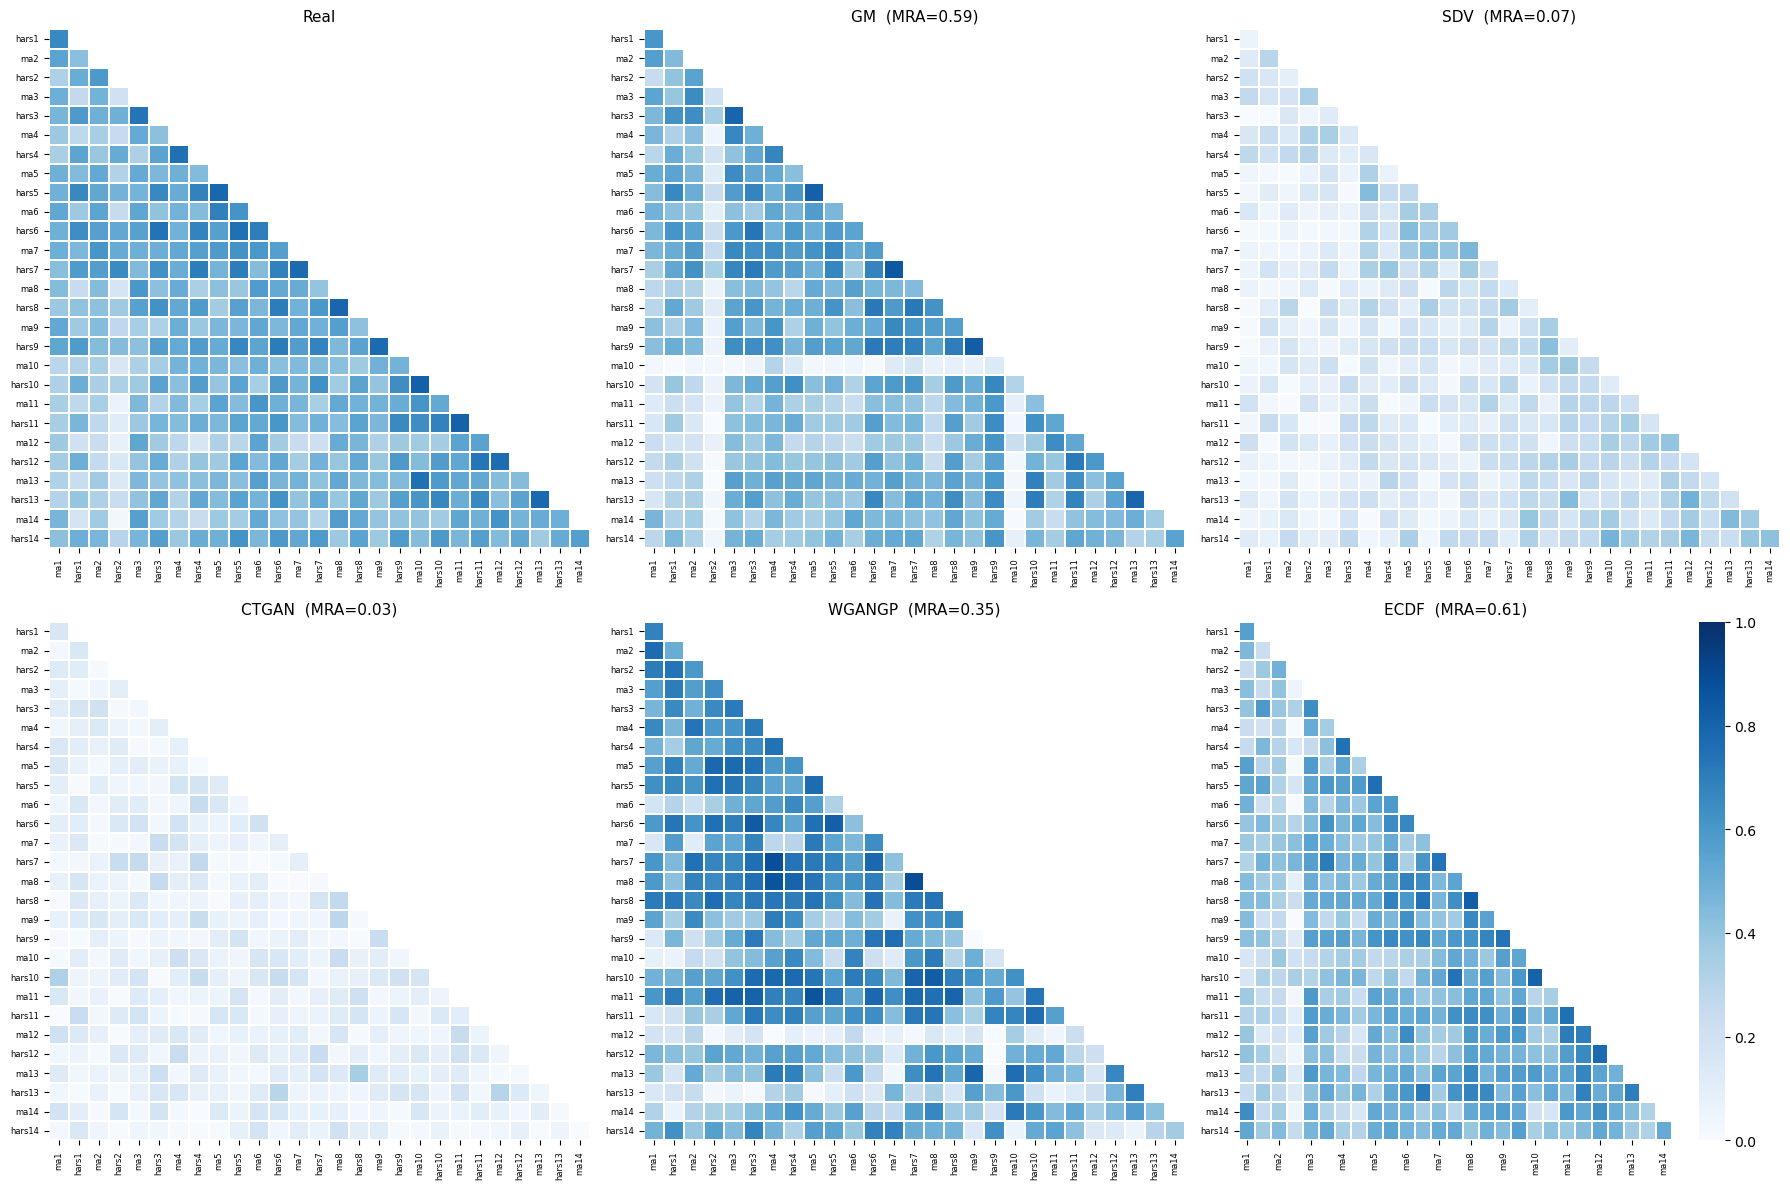

In [8]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axs_flat = axs.ravel()

for name_idx, name in enumerate(DATA_TYPES):
    ax = axs_flat[name_idx]
    matrix = cors_numerical[name]
    
    # 最后一列才显示colorbar
    show_cbar = (name_idx == len(DATA_TYPES) - 1)
    plot_correlations(matrix, ax, color_bar=show_cbar)
    
    if name == 'Real':
        ax.set_title(name, fontsize=11)
    else:
        score = compute_mra_score(cors_numerical['Real'], matrix)
        ax.set_title(f'{name}  (MRA={score})', fontsize=11)
    
    ax.tick_params(axis='both', labelsize=6)

fig.tight_layout()
fig.savefig('MULTIVARIATE RESEMBLANCE RESULTS/PPC_Matrices.svg', bbox_inches='tight')

## 4. Explore the results

In [11]:
norms_numerical

{'Real': 14.4511,
 'GM': 13.7268,
 'SDV': 7.8038,
 'CTGAN': 6.1363,
 'WGANGP': 15.6903,
 'ECDF': 13.8335}